In [1]:
import openml
import pickle as pkl
import numpy as np
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import torch

- **Bioresponse** (did=4134, tid=9910)
- **Madelon** (did=1485, tid=9976)

In [8]:
with open(
    "../results/fold0_layers2_hidden512_epc1000_ninits20__seed42_madelon.pkl", "rb"
) as f:
    run = pkl.load(f)

with open(
    "../results/fold0_layers2_hidden512_epc1000_ninits20__seed55_madelon.pkl", "rb"
) as f:
    run2 = pkl.load(f)

In [9]:
len(run["trace"]["logits"])

500

In [10]:
run["trace"]["logits"]

[array([[-0.1357 , -0.06854],
        [-0.0985 ,  0.02246],
        [-0.06183, -0.1343 ],
        ...,
        [-0.02272,  0.03693],
        [-0.0441 , -0.0529 ],
        [-0.1721 ,  0.0389 ]], shape=(2340, 2), dtype=float16),
 array([[-0.137  , -0.0673 ],
        [-0.098  ,  0.02184],
        [-0.06232, -0.1337 ],
        ...,
        [-0.02242,  0.0364 ],
        [-0.04425, -0.05276],
        [-0.1743 ,  0.04108]], shape=(2340, 2), dtype=float16),
 array([[-0.1382 , -0.0661 ],
        [-0.0976 ,  0.02126],
        [-0.0628 , -0.1329 ],
        ...,
        [-0.02214,  0.03592],
        [-0.04443, -0.05264],
        [-0.1765 ,  0.04327]], shape=(2340, 2), dtype=float16),
 array([[-0.1395 , -0.0649 ],
        [-0.09717,  0.0207 ],
        [-0.0633 , -0.1323 ],
        ...,
        [-0.0219 ,  0.03543],
        [-0.04462, -0.0525 ],
        [-0.1788 ,  0.0455 ]], shape=(2340, 2), dtype=float16),
 array([[-0.1407 , -0.06366],
        [-0.0968 ,  0.02019],
        [-0.0638 , -0.1316 ],
  

In [11]:
array_one_run = np.array(run["trace"]["logits"])
array_one_run2 = np.array(run2["trace"]["logits"])

In [16]:
array_one_run.reshape(array_one_run.shape[0], -1).shape

(500, 4680)

In [ ]:
FOLD = 0
did = 1485
tid = 9976
dataset_name = "madelon"
ds = openml.datasets.get_dataset(
    did,
    download_data=True,
    download_qualities=False,
    download_features_meta_data=False,
)
X, y, _, _ = ds.get_data(target=ds.default_target_attribute, dataset_format="dataframe")
print(f"Loaded {dataset_name} (did={did}) (tid={did})")

task = openml.tasks.get_task(tid, download_splits=True)
train_idx, test_idx = task.get_train_test_split_indices(fold=FOLD, repeat=0)

le = LabelEncoder()
y_enc: np.ndarray = np.asarray(le.fit_transform(y.values))
n_classes = len(le.classes_)

X_vals = X.select_dtypes(include="number").fillna(0).values.astype("float32")
X_tr, y_tr = X_vals[train_idx], y_enc[train_idx]
X_te, y_te = X_vals[test_idx], y_enc[test_idx]

Loaded madelon (did=1485) (tid=1485)


In [ ]:
resume = np.zeros(shape=[array_one_run.shape[0], array_one_run.shape[1]])
resume2 = np.zeros(shape=[array_one_run2.shape[0], array_one_run2.shape[1]])

In [ ]:
display(array_one_run.shape)
display(array_one_run2.shape)

(1000, 2340, 2)

(1000, 2340, 2)

In [ ]:
for i in range(resume.shape[0]):
    resume[i, :] = F.cross_entropy(
        torch.tensor(array_one_run[i, :, :]), torch.tensor(y_tr), reduction="none"
    )
    resume2[i, :] = F.cross_entropy(
        torch.tensor(array_one_run2[i, :, :]), torch.tensor(y_tr), reduction="none"
    )

In [ ]:
resume_norm = np.sum(resume, axis=1)
resume_norm2 = np.sum(resume2, axis=1)

In [ ]:
display(resume_norm[-1])
display(resume_norm2[-1])

np.float64(13.967955937612146)

np.float64(13.348705884676065)

<Axes: >

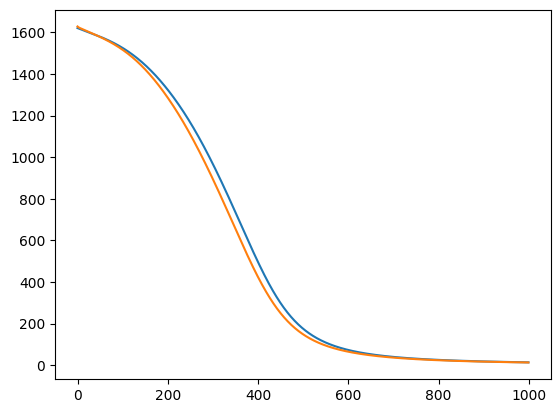

In [ ]:
sns.lineplot(resume_norm)
sns.lineplot(resume_norm2)

In [ ]:
two_traj = np.concatenate([resume, resume2], axis=0)

In [ ]:
two_traj.shape

(2000, 2340)

In [ ]:
two_traj

array([[7.23939180e-01, 7.53993809e-01, 6.52775526e-01, ...,
        6.65539086e-01, 6.99471593e-01, 5.97501457e-01],
       [7.22195506e-01, 7.52344906e-01, 6.49019182e-01, ...,
        6.67357922e-01, 7.00869024e-01, 5.99466085e-01],
       [7.20808327e-01, 7.51060128e-01, 6.45663023e-01, ...,
        6.68848574e-01, 7.01926827e-01, 6.01086020e-01],
       ...,
       [4.99548626e+00, 5.54475887e-03, 1.64507474e-05, ...,
        5.78264809e+00, 2.31034704e-03, 5.62892962e+00],
       [4.99780464e+00, 5.53005887e-03, 1.63315399e-05, ...,
        5.78528261e+00, 2.30368669e-03, 5.63163042e+00],
       [5.00029373e+00, 5.51583245e-03, 1.63315399e-05, ...,
        5.78795242e+00, 2.29726406e-03, 5.63422966e+00]],
      shape=(2000, 2340))

In [ ]:
pca = PCA(n_components=2)
pca_resume = pca.fit_transform(two_traj)

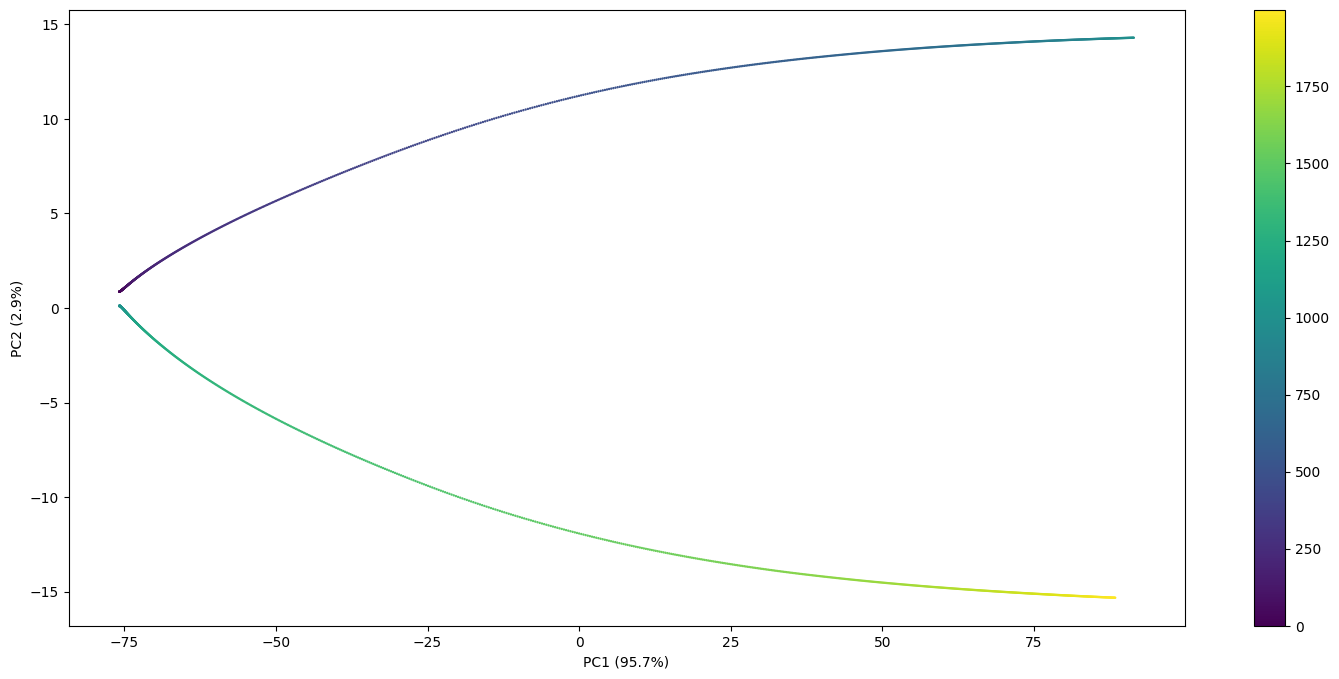

In [ ]:
fig, axes = plt.subplots(1, figsize=(18, 8))

plt.scatter(
    pca_resume[:, 0],
    pca_resume[:, 1],
    c=range(len(pca_resume[:, 0])),
    cmap="viridis",
    s=0.5,
    zorder=3,
)

axes.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar()